In [1]:
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-2-7b-hf')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-2-7b-hf', device_map="auto")
model.hf_device_map

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

{'model.embed_tokens': 0,
 'model.layers.0': 0,
 'model.layers.1': 0,
 'model.layers.2': 0,
 'model.layers.3': 0,
 'model.layers.4': 0,
 'model.layers.5': 0,
 'model.layers.6': 0,
 'model.layers.7': 0,
 'model.layers.8': 0,
 'model.layers.9': 0,
 'model.layers.10': 0,
 'model.layers.11': 0,
 'model.layers.12': 0,
 'model.layers.13': 0,
 'model.layers.14': 0,
 'model.layers.15': 0,
 'model.layers.16': 1,
 'model.layers.17': 1,
 'model.layers.18': 1,
 'model.layers.19': 1,
 'model.layers.20': 1,
 'model.layers.21': 1,
 'model.layers.22': 1,
 'model.layers.23': 1,
 'model.layers.24': 1,
 'model.layers.25': 1,
 'model.layers.26': 1,
 'model.layers.27': 1,
 'model.layers.28': 1,
 'model.layers.29': 1,
 'model.layers.30': 1,
 'model.layers.31': 1,
 'model.norm': 1,
 'model.rotary_emb': 1,
 'lm_head': 1}

In [3]:
q_proj_weight_7 = model.model.layers[7].self_attn.q_proj.weight
q_proj_weight_15 = model.model.layers[15].self_attn.q_proj.weight
q_proj_weight_23 = model.model.layers[23].self_attn.q_proj.weight

k_proj_weight_7 = model.model.layers[7].self_attn.k_proj.weight
k_proj_weight_15 = model.model.layers[15].self_attn.k_proj.weight
k_proj_weight_23 = model.model.layers[23].self_attn.k_proj.weight

v_proj_weight_7 = model.model.layers[7].self_attn.v_proj.weight
v_proj_weight_15 = model.model.layers[15].self_attn.v_proj.weight
v_proj_weight_23 = model.model.layers[23].self_attn.v_proj.weight

o_proj_weight_7 = model.model.layers[7].self_attn.o_proj.weight
o_proj_weight_15 = model.model.layers[15].self_attn.o_proj.weight
o_proj_weight_23 = model.model.layers[23].self_attn.o_proj.weight

mlp_gate_weight_7 = model.model.layers[7].mlp.gate_proj.weight
mlp_gate_weight_15 = model.model.layers[15].mlp.gate_proj.weight
mlp_gate_weight_23 = model.model.layers[23].mlp.gate_proj.weight

mlp_up_weight_7 = model.model.layers[7].mlp.up_proj.weight
mlp_up_weight_15 = model.model.layers[15].mlp.up_proj.weight
mlp_up_weight_23 = model.model.layers[23].mlp.up_proj.weight

mlp_down_weight_7 = model.model.layers[7].mlp.down_proj.weight
mlp_down_weight_15 = model.model.layers[15].mlp.down_proj.weight
mlp_down_weight_23 = model.model.layers[23].mlp.down_proj.weight

In [4]:
from test_dbsf import *

In [5]:
# diagram0a = test_double_sparse(matrix=k_proj_weight_7, mask_type='blocks', total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

In [6]:
# diagram0b = test_double_sparse(matrix=q_proj_weight_7, mask_type='2to4', total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

In [7]:
# # q7 = test_double_block_sparse(q_proj_weight_7, 0.5, 0.5, 1)
# q15 = test_double_block_sparse(q_proj_weight_15, 0.5, 0.5, 1)
# # q23 = test_double_block_sparse(q_proj_weight_23, 0.5, 0.5, 1)

# # k7 = test_double_block_sparse(k_proj_weight_7, 0.5, 0.5, 1)
# k15 = test_double_block_sparse(k_proj_weight_15, 0.5, 0.5, 1)
# # k23 = test_double_block_sparse(k_proj_weight_23, 0.5, 0.5, 1)

# # mg7 = test_double_block_sparse(mlp_gate_weight_7, 0.5, 0.5, 1)
# mg15 = test_double_block_sparse(mlp_gate_weight_15, 0.5, 0.5, 1)
# # mg23 = test_double_block_sparse(mlp_gate_weight_23, 0.5, 0.5, 1)

# # md7 = test_double_block_sparse(mlp_down_weight_7, 0.5, 0.5, 1)
# md15 = test_double_block_sparse(mlp_down_weight_15, 0.5, 0.5, 1)
# # md23 = test_double_block_sparse(mlp_down_weight_23, 0.5, 0.5, 1)

# res = {
#     # "q7": q7,
#     "q15": q15,
#     # "q23": q23,
#     # "k7": k7,
#     "k15": k15,
#     # "k23": k23,
#     # "mg7": mg7,
#     "mg15": mg15,
#     # "mg23": mg23,
#     # "md7": md7,
#     "md15": md15,
#     # "md23": md23,
# }

# print(res)

In [8]:
rho0 = {
    'q15': 105.1045913696289, 
    'k15': 108.2546615600586, 
    'mg15': 101.32691192626953, 
    'md15': 98.73725128173828
}
rho0_1 = {
    'q15': 41.81094741821289, 
    'k15': 43.086483001708984, 
    'mg15': 73.41590118408203, 
    'md15': 74.24418640136719
}
rho0_25 = {
    'q15': 24.419002532958984, 
    'k15': 25.219478607177734, 
    'mg15': 48.51237487792969, 
    'md15': 49.44807434082031
}
rho0_4 = {
    'q15': 23.110801696777344, 
    'k15': 23.8511905670166, 
    'mg15': 42.945472717285156, 
    'md15': 43.15519332885742
}
rho0_45 = {
    'q15': 23.10077476501465, 
    'k15': 23.839792251586914, 
    'mg15': 42.548973083496094, 
    'md15': 42.68795394897461
}
rho0_5 = {
    'q15': 23.122785568237305,
    'k15': 23.85993766784668,
    'mg15': 42.440006256103516, 
    'md15': 42.553592681884766, 
}
rho0_55 = {
    'q15': 23.170974731445312, 
    'k15': 23.907880783081055, 
    'mg15': 42.5140266418457, 
    'md15': 42.62941360473633
}
rho0_75 = {
    'q15': 23.569107055664062, 
    'k15': 24.309635162353516, 
    'mg15': 42.84531784057617, 
    'md15': 42.98478698730469
}
rho1 = {
    'q15': 24.298742294311523, 
    'k15': 25.035852432250977, 
    'mg15': 43.17190170288086, 
    'md15': 43.27824401855469, 
}

In [9]:
# q7_2x2 = test_double_sparse(q_proj_weight_7, 0.5, 0.5, 1, mask_type='blocks_alt')
# q15_2x2 = test_double_sparse(q_proj_weight_15, 0.5, 0.5, 1, mask_type='blocks_alt')
# q23_2x2 = test_double_sparse(q_proj_weight_23, 0.5, 0.5, 1, mask_type='blocks_alt')

In [10]:
q7_1x1 = 10.132308006286621
q15_1x1 = 10.241986274719238
q23_1x1 = 10.641284942626953

q7_2x1_colrow = 17.123369216918945
q15_2x1_colrow = 17.54688835144043
q23_2x1_colrow = 18.129613876342773

q7_2x1_rowrow = 17.125669479370117
q15_2x1_rowrow = 17.55666732788086
q23_2x1_rowrow = 18.12950897216797

q7_2x1_colcol = 17.140546798706055
q15_2x1_colcol = 17.563806533813477
q23_2x1_colcol = 18.14604377746582

q7_2x1_rowcol = 17.15144157409668
q15_2x1_rowcol = 17.572513580322266
q23_2x1_rowcol = 18.153913497924805

q7_2x2 = 23.453115463256836
q15_2x2 = 24.298742294311523
q23_2x2 = 25.018169403076172

q7_4x4 = 30.620349884033203
q15_4x4 = 32.03445816040039
q23_4x4 = 33.268218994140625

q7_8x8 = 37.110137939453125
q15_8x8 = 39.21969223022461
q23_8x8 = 40.96297073364258

q7_16x16 = 39.02204132080078
q15_16x16 = 40.88953399658203
q23_16x16 = 47.2333869934082

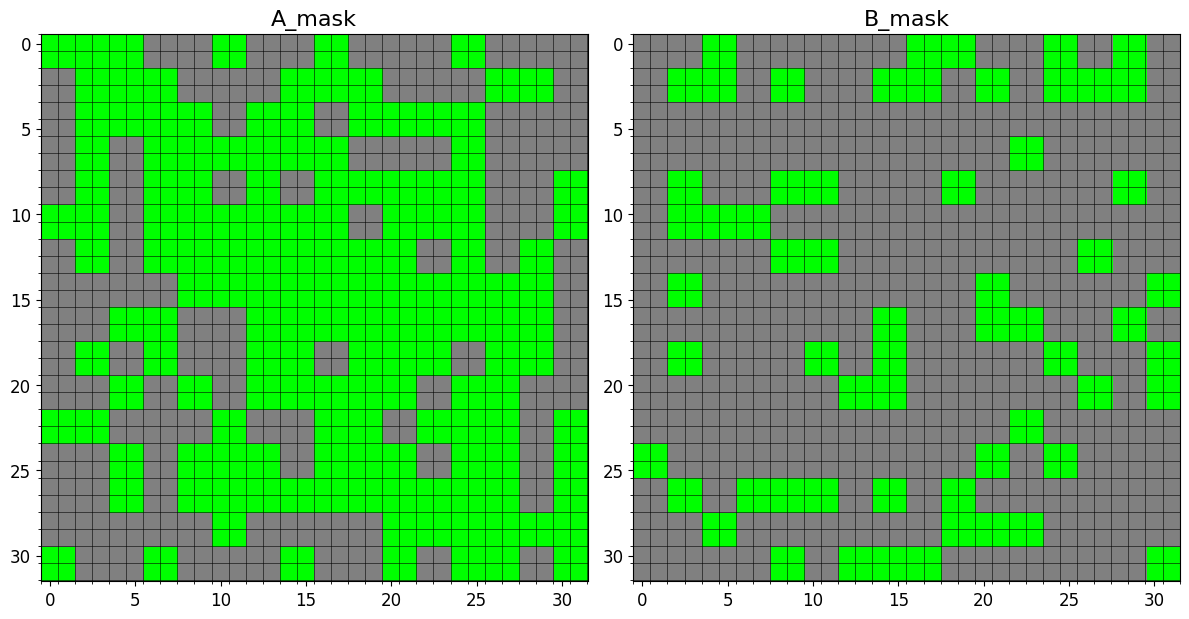

Frobenius norm: 23.453115463256836
A: tensor([[ 2.1323,  0.2182,  0.1966,  0.6991],
        [-0.2114,  3.6168, -0.7643, -0.4303],
        [ 0.0000, -0.0000,  2.0744, -0.3827],
        [-0.0000, -0.0000,  0.3969,  2.9422]])
B: tensor([[ 0.0000, -0.0000,  0.0000,  0.0000],
        [-0.0000,  0.0000, -0.0000,  0.0000],
        [ 0.0000, -0.0000, -0.0016,  0.0024],
        [ 0.0000, -0.0000,  0.0049, -0.0038]])
A.size() = torch.Size([4096, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[ 0.0035,  0.0043,  0.0042,  ..., -0.0028, -0.0176,  0.0030],
        [ 0.0082,  0.0018, -0.0027,  ...,  0.0066, -0.0063, -0.0047],
        [ 0.0011,  0.0050, -0.0087,  ..., -0.0096,  0.0015, -0.0037],
        ...,
        [-0.0079, -0.0354, -0.0187,  ..., -0.0194,  0.0382,  0.0359],
        [ 0.0092,  0.0613, -0.0323,  ..., -0.0166, -0.0516, -0.0580],
        [ 0.0815, -0.0077, -0.0081,  ...,  0.0823,  0.0407, -0.0074]])
Input matrix was: tensor([[ 6.8970e-03,  2.3804e-03,  3.3569e-03,  ...,  4.0283

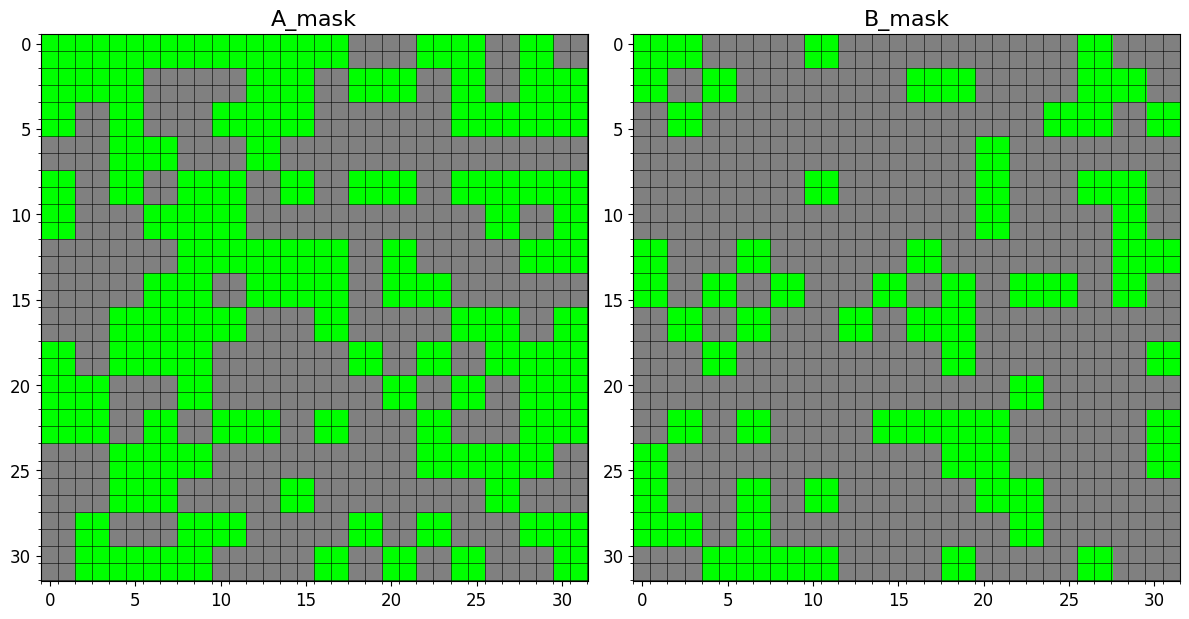

Frobenius norm: 41.790103912353516
A: tensor([[ 0.7772, -0.0041, -0.0103, -0.0214],
        [ 0.0168,  0.7656,  0.0019,  0.0159],
        [ 0.0283,  0.0213,  0.7604,  0.0102],
        [-0.0482, -0.0312, -0.0026,  0.7500]])
B: tensor([[-0.0312, -0.0332, -0.0324, -0.0338],
        [-0.0082,  0.0127, -0.0230,  0.0166],
        [ 0.0324,  0.0677,  0.0000, -0.0000],
        [-0.0210, -0.0034, -0.0000, -0.0000]])
A.size() = torch.Size([4096, 4096])
B.size() = torch.Size([4096, 11008])
AB: tensor([[-9.4134e-03, -1.4615e-02, -2.6014e-02,  ...,  2.0437e-02,
          1.3055e-02, -1.8220e-02],
        [ 5.8137e-03, -9.8979e-03, -2.0338e-02,  ..., -8.8375e-03,
         -2.1071e-02,  1.5864e-02],
        [ 4.1232e-02,  4.1258e-02, -2.5325e-02,  ..., -1.8889e-03,
          3.0242e-02,  1.6759e-02],
        ...,
        [-7.9602e-03, -4.2629e-02,  1.2827e-02,  ...,  5.2585e-03,
         -4.7355e-03, -6.8419e-04],
        [-2.9585e-02, -1.0558e-02, -9.2715e-04,  ..., -2.2878e-02,
         -1.3617e-02

In [11]:
q7_2x2 = test_double_sparse(q_proj_weight_7, 0.5, 0.5, 1, mask_type='blocks')
q15_2x2 = test_double_sparse(mlp_down_weight_15, 0.5, 0.5, 1, mask_type='blocks')

In [12]:
q7_2x2_125p_375p = 23.643545150756836
q15_2x2_125p_375p = 24.829833984375
q23_2x2_125p_375p = 25.581159591674805

q7_2x2_20p_30p = 23.164443969726562
q15_2x2_20p_30p = 24.083036422729492
q23_2x2_20p_30p = 24.837310791015625

q7_2x2_25p_25p = 23.453115463256836
q15_2x2_25p_25p = 24.298742294311523
q23_2x2_25p_25p = 25.018169403076172

q7_2x2_375p_125p = 26.42716407775879
q15_2x2_375p_125p = 27.068979263305664
q23_2x2_375p_125p = 27.9689884185791


o7_2x2_125p_375p = 17.115551
o15_2x2_125p_375p = 19.705472946166992
o23_2x2_125p_375p = 25.003847122192383

o7_2x2_20p_30p = 16.28129005432129
o15_2x2_20p_30p = 18.71734046936035
o23_2x2_20p_30p = 23.90760612487793

o7_2x2_25p_25p = 16.217567443847656
o15_2x2_25p_25p = 18.643760681152344
o23_2x2_25p_25p = 23.848196029663086

o7_2x2_375p_125p = 17.73960304260254
o15_2x2_375p_125p = 20.45415496826172
o23_2x2_375p_125p = 26.226451873779297


mlpup7_2x2_407p_25p = 41.632450103759766
mlpup15_2x2_407p_25p = 44.01103210449219
mlpup23_2x2_407p_25p = 44.097938537597656

mlpup7_2x2_360p_375p = 40.40531539916992
mlpup15_2x2_360p_375p = 42.69010543823242
mlpup23_2x2_360p_375p = 42.748512268066406

mlpup7_2x2_314p_50p = 40.26658248901367
mlpup15_2x2_314p_50p = 42.532840728759766
mlpup23_2x2_314p_50p = 42.59101486206055


mlpdown7_2x2_407p_25p = 40.1270751953125
mlpdown15_2x2_407p_25p = 43.27824401855469
mlpdown23_2x2_407p_25p = 44.18965148925781

mlpdown7_2x2_360p_375p = 38.80428695678711
mlpdown15_2x2_360p_375p = 41.95237731933594
mlpdown23_2x2_360p_375p = 42.881065368652344

mlpdown7_2x2_314p_50p = 38.57448196411133
mlpdown15_2x2_314p_50p = 41.790103912353516
mlpdown23_2x2_314p_50p = 42.743751525878906